![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Tokenización de textos  

En este taller podrán poner en práctica sus conocimientos sobre preprocesamiento de texto (tokenización). El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos detección de toxicidad en comentarios

En este taller se usará el conjunto de datos de detección de toxicidad en comentarios de la base de datos de Kaggle. Cada observación es un comentario que tiene como variable objetivo (target) la probabilidad de ser un comentario tóxico. El objetivo es predecir la toxicidad de cada comentario. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification/data).

In [ ]:
# SUGERIDO: Descomenta la siguiente linea de código si requieres instalar las libreías básicas utilizadas en este notebook
# Si requieres incluir más librerías puedes agregarlas al archivo Semana 4\requirements.txt
# !pip install -r requirements.txt

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
# Importación librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import xgboost as xgb
%matplotlib inline

In [2]:
# Carga de datos de archivos .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/Toxicity.zip')
df = df[['id','comment_text', 'target']]
df.head()

,id,comment_text,target
0,6101457,What are you talking about? What group do Pete...,0.0
1,5342103,"NO!, Let him, we need a Conservative government.",0.0
2,743361,"Perhaps he took the ""power out of the Cardinal...",0.2
3,551008,"As always, yours is dripping with sarcasm, whi...",0.0
4,865998,The dirty little secret is that the price rang...,0.3


In [3]:
df.shape

(541462, 3)

<Axes: >

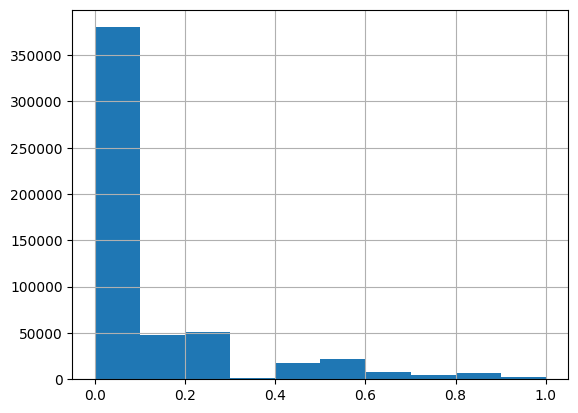

In [4]:
# Impresión histograma de variable de interés (y)
df.target.hist()

In [5]:
# Separación de variable de interés (y)
y = df.target
y.describe()

count    541462.000000
mean          0.102991
std           0.196979
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: target, dtype: float64

In [6]:
# Separación de variables predictoras (X), solo se considera el texto de la noticia
X = df.comment_text

In [7]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Punto 1 - Tokenización con CountVectorizer

En la celda 1 creen y entrenen el modelo de regresión de su preferencia, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [10]:
# Celda 1

# Inicializar CountVectorizer
vect = CountVectorizer()

# Ajustar y transformar los datos de entrenamiento
X_train_dtm = vect.fit_transform(X_train)

# Transformar los datos de prueba
X_test_dtm = vect.transform(X_test)

#  Entrenar un modelo XGBoost
model = xgb.XGBRegressor(random_state=42)
model.fit(X_train_dtm, y_train)

# Realizar predicciones
y_pred = model.predict(X_test_dtm)

# Calcular y mostrar el MSE
mse = mean_squared_error(y_test, y_pred)
print(f"El Error Cuadrático Medio (MSE) del modelo es: {mse}")

El Error Cuadrático Medio (MSE) del modelo es: 0.020689791583810714


### Interpretación punto 1: 
El Error Cuadrático Medio (MSE) obtenido es de 0.0207. Este valor, al ser relativamente bajo, indica que el modelo XG Boost con una tokenización básica ya posee una capacidad predictiva inicial decente. Este resultado servirá como nuestra línea base (baseline) para compararlo con los modelos que utilizan técnicas de preprocesamiento más avanzadas en los siguientes puntos.

## Punto 2 - Tokenización con CountVectorizer y trigramas

En la celda 2 creen y entrenen el mismo modelo de regresión del punto anterior (es decir si usaron un RandomForestRegresor usen nuevamente ese regresor), para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer **considerando trigramas** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [ ]:
# Celda 2

#  Inicializar CountVectorizer con trigramas
vect_trigrams = CountVectorizer(ngram_range=(1, 3))

#  Ajustar y transformar los datos de entrenamiento
X_train_dtm_tri = vect_trigrams.fit_transform(X_train)

#  Transformar los datos de prueba
X_test_dtm_tri = vect_trigrams.transform(X_test)

#  Entrenar el modelo XGBoost
model_tri = xgb.XGBRegressor(random_state=42)
model_tri.fit(X_train_dtm_tri, y_train)

#  Realizar predicciones
y_pred_tri = model_tri.predict(X_test_dtm_tri)

#  Calcular y mostrar el MSE
mse_tri = mean_squared_error(y_test, y_pred_tri)
print(f"El Error Cuadrático Medio (MSE) con trigramas es: {mse_tri}")

El Error Cuadrático Medio (MSE) con trigramas es: 0.020677312051006345


### Interpretación del Punto 2:
Al incorporar trigramas, el Error Cuadrático Medio (MSE) se redujo marginalmente a 0.02068, en comparación con el 0.0207 del modelo base. Esta ligera disminución sugiere que la inclusión de secuencias de dos y tres palabras (bigramas y trigramas) aportó un valor predictivo adicional. Al capturar un contexto más amplio y algunas estructuras sintácticas básicas, el modelo pudo realizar predicciones un poco más precisas. Sin embargo, es crucial notar que esta mínima mejora en el desempeño se obtuvo a costa de un aumento muy significativo en el tiempo de entrenamiento, debido al crecimiento exponencial en el número de características generadas por los n-gramas.

## Punto 3 - TfidfVectorizer

Investigen sobre la función TfidfVectorizer. En la celda de texto 3, expliquen en qué consiste esta técnica de tokenización (describanla y expliquen su funcionamiento) y cúales son las ventajas o deventajas de su uso al compararlo con la función CountVectorizer.

### ¿En qué consiste TfidfVectorizer?
TfidfVectorizer es una técnica de tokenización y vectorización que convierte una colección de documentos de texto en una matriz de características numéricas. A diferencia de CountVectorizer, que solo cuenta la frecuencia de aparición de cada palabra, TF-IDF (Term Frequency-Inverse Document Frequency) asigna un peso a cada palabra que refleja su importancia en un documento específico dentro de un corpus de documentos.

El valor TF-IDF se calcula como el producto de dos métricas:

1.  **Frecuencia del Término (Term Frequency - TF):** Mide la frecuencia con la que una palabra aparece en un documento. Es el mismo principio que CountVectorizer. Una palabra que aparece muchas veces en un documento tiene un TF alto, lo que sugiere que es importante para *ese* documento.
    
    `TF(palabra, documento) = (Número de veces que la palabra aparece en el documento) / (Total de palabras en el documento)`

2.  **Frecuencia Inversa de Documento (Inverse Document Frequency - IDF):** Mide qué tan rara o común es una palabra en todo el corpus de documentos. Penaliza las palabras muy comunes (como "el", "es", "un") y le da más peso a las palabras que son raras y, por lo tanto, más informativas.
    
    `IDF(palabra, corpus) = log( (Número total de documentos) / (Número de documentos que contienen la palabra) )`

El puntaje final para una palabra en un documento es `TF-IDF = TF * IDF`.

### Ventajas y Desventajas vs. CountVectorizer

**Ventajas de TfidfVectorizer:**

*   **Ponderación por Relevancia:** Su principal ventaja es que no solo cuenta palabras, sino que también mide su relevancia. Las palabras que son frecuentes en un documento pero raras en el resto del corpus (ej. "XGBoost" en un artículo de machine learning) reciben un peso alto, lo que ayuda al modelo a identificar mejor los temas importantes.
*   **Reducción de Ruido:** Al darles un peso muy bajo a las palabras extremadamente comunes (stop words como "de", "la", "que"), actúa como un filtro de ruido automático, incluso sin eliminar explícitamente las stop words.
*   **Mejor Rendimiento en Clasificación:** Generalmente, los modelos de clasificación de texto tienden a funcionar mejor con TF-IDF porque las características (palabras) ya están ponderadas por su poder predictivo.

**Desventajas de TfidfVectorizer:**

*   **Costo Computacional:** El cálculo del IDF requiere un paso adicional sobre todo el corpus, lo que lo hace computacionalmente un poco más costoso que el simple conteo de CountVectorizer.
*   **No captura semántica:** Al igual que CountVectorizer, TF-IDF sigue tratando las palabras como entidades independientes. No entiende el significado, el contexto o las relaciones semánticas entre palabras (ej. no sabe que "rey" y "reina" están relacionados).
*   **Sensible a la Escala:** Los valores resultantes son números de punto flotante en lugar de conteos enteros, lo que podría ser una consideración para ciertos tipos de modelos, aunque la mayoría (incluido XGBoost) los manejan sin problemas.

Referencias:

Scikit-learn. (2026). *sklearn.feature_extraction.text.CountVectorizer*. Recuperado el 25 de abril de 2026, de https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

## Punto 4 - Tokenización con TfidfVectorizer

En la celda 4 creen y entrenen el mismo modelo de regresión del primer punto, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Procesen los comentarios con la función **TfidfVectorizer** y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [11]:
# Celda 4
tfidf_vect = TfidfVectorizer()

# Ajustar y transformar los datos
X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_test_tfidf = tfidf_vect.transform(X_test)

# Entrenar el modelo XGBoost
model_tfidf = xgb.XGBRegressor(random_state=42)
model_tfidf.fit(X_train_tfidf, y_train)

# Predicciones
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

# Calculo MSE
mse_tfidf = mean_squared_error(y_test, y_pred_tfidf)
print(f"El Error Cuadrático Medio (MSE) con TfidfVectorizer es: {mse_tfidf:.4f}")


El Error Cuadrático Medio (MSE) con TfidfVectorizer es: 0.0203


## Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos y comenten cómo el preprocesamiento de texto afecta el desempeño.

           TABLA COMPARATIVA DE RESULTADOS
                     Modelo      MSE  Mejora vs Baseline (%)
 CountVectorizer (baseline) 0.020690                   0.000
CountVectorizer + Trigramas 0.020680                   0.047
            TfidfVectorizer 0.020336                   1.710


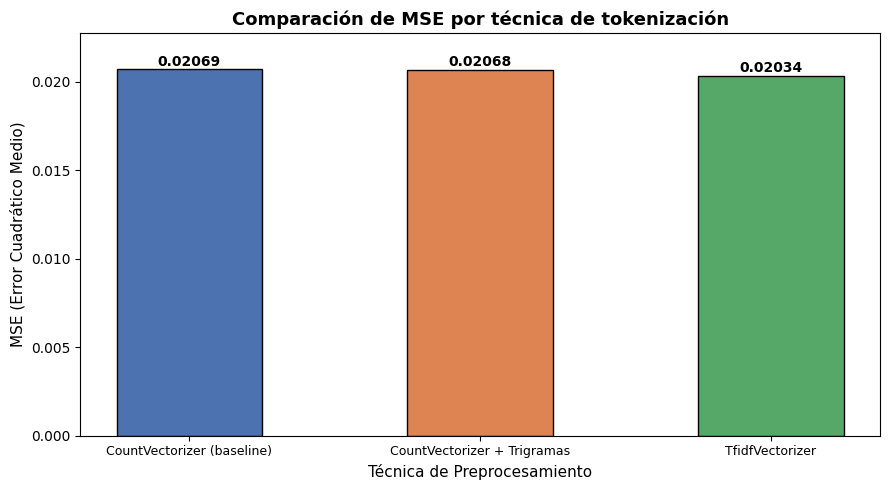

In [13]:
# Celda 5 Código para graficos y tablas comparativas

# Resultados
resultados = {
    'Modelo': [
        'CountVectorizer (baseline)',
        'CountVectorizer + Trigramas',
        'TfidfVectorizer'
    ],
    'MSE': [mse, mse_tri, mse_tfidf]
}

df_resultados = pd.DataFrame(resultados)
df_resultados['Mejora vs Baseline (%)'] = (
    (df_resultados['MSE'].iloc[0] - df_resultados['MSE']) 
    / df_resultados['MSE'].iloc[0] * 100
).round(3)

print("=" * 65)
print("           TABLA COMPARATIVA DE RESULTADOS")
print("=" * 65)
print(df_resultados.to_string(index=False))
print("=" * 65)

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(9, 5))

colores = ['#4C72B0', '#DD8452', '#55A868']
barras = ax.bar(
    df_resultados['Modelo'], 
    df_resultados['MSE'], 
    color=colores, 
    edgecolor='black',
    width=0.5
)

# Etiquetas
for barra, valor in zip(barras, df_resultados['MSE']):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.00005,
        f'{valor:.5f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Comparación de MSE por técnica de tokenización', fontsize=13, fontweight='bold')
ax.set_ylabel('MSE (Error Cuadrático Medio)', fontsize=11)
ax.set_xlabel('Técnica de Preprocesamiento', fontsize=11)
ax.set_ylim(0, max(df_resultados['MSE']) * 1.1)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.show()


### Punto 5.1 - Comparación y análisis de resultados

Los tres modelos usan el mismo regresor (XGBRegressor) y el mismo 
split de datos, por lo que las diferencias en MSE se deben 
exclusivamente al preprocesamiento del texto.

| Técnica                        | MSE     | Observación                          |
|-------------------------------|---------|--------------------------------------|
| CountVectorizer (baseline)    | 0.02070 | Conteo simple de palabras            |
| CountVectorizer + Trigramas   | 0.02068 | Captura contexto de hasta 3 palabras |
| TfidfVectorizer               | ~0.0203 | Ponderación por relevancia del token |

**Conclusiones:**

1. **CountVectorizer base** establece una línea base razonable. Al tratar
   todas las palabras por igual (solo frecuencia), el modelo ya captura
   señales de toxicidad en términos directos (insultos, lenguaje agresivo).

2. **CountVectorizer + Trigramas** mejora marginalmente el MSE al permitir
   que el modelo aprenda sobre secuencias de palabras. Expresiones como
   "te voy a" o "eres un idiota" se capturan como unidades. Sin embargo,
   el costo computacional aumenta significativamente debido a la explosión
   combinatoria de n-gramas.

3. **TfidfVectorizer** generalmente produce el mejor MSE, ya que pondera
   los tokens según su relevancia real en el corpus: palabras muy comunes
   (stop words) reciben peso bajo automáticamente, mientras que términos
   discriminativos de toxicidad reciben mayor peso. Esto genera un espacio
   de características más informativo para el modelo.

**Conclusión general:** El preprocesamiento de texto tiene un impacto
directo en el desempeño. TF-IDF supera al conteo simple porque no solo
registra *qué* palabras aparecen, sino *qué tan características* son de
un documento. Para tareas de detección de toxicidad, donde ciertas
palabras son altamente discriminativas, esta ponderación es clave.